# Computational Thermofluid Dynamics - Chapter 4

Technical University of Munich, Professur für Thermofluiddynamik - Pr. Polifke

==============================================================================================

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML
import warnings

## Form function to change the shape of domain


In [2]:
def formfunction(x, shape):
    """
    Defines the shape of north boundary
    takes an array and shape
    returns an array
    """
    h1 = x[-1]           # west boundary height
    h2 = x[-1] / 10 * 4  # east boundary height
    l  = x[-1]           # domain length
    if shape == 'linear':
        m = (h2 - h1) / (2 * l)
        b = h1 / 2
        return m * x + b
    
    elif shape == 'rectangular':
        return l * np.ones((x.size, 1))
        
    elif shape == 'quadratic':
        k = 2 * l**2 / (h1 - h2)
        return (x - l)**2 / k + h2 / 2 
    
    elif shape == 'crazy':
        return h1/2 + (h2/2 - h1/2) * x / l + 0.25*(-h1 + h2/2) * np.sin(np.pi*x/l)**2
    
    else:
        raise ValueError('Unknown shape: %s' % shape)

def setUpMesh(nodes_x, nodes_y, length, formfunction, shape):
    # X - matrix of x coordinates
    # Y - matrix of y coordinates
    X = np.linspace(0, length, nodes_x)
    # Y cooridnates of the northern boundary
    north_shape = formfunction(X, shape)
    Y = np.ones((nodes_y, nodes_x))
    for j in np.arange(nodes_x):
        Y[:, j] = np.linspace(north_shape[j], 0, nodes_y)
        
    X = np.array([X[:] for i in range(nodes_y)]) 
    
    return X , Y

In [3]:
# if you fail to implement linear, go with rectangular case!
shape =  'linear'    # 'rectangular', 'linear',  'quadratic', 'crazy'

l = 1
dimX = 51
dimY = 51

boundary =   ['D', 'N', 'D', 'D'] # [N,S,W,E] : D : Dirichlet, N : Neumann, R : Robin
TD =  [100 , 100 , 300 , 100] # [N,S,W,E]
alpha = 20
Tinf = 90
q = 0

X, Y = setUpMesh(dimX, dimY, l, formfunction, shape)


Displaying Figure 1: Mesh Gridlines


(0.0, 0.55)

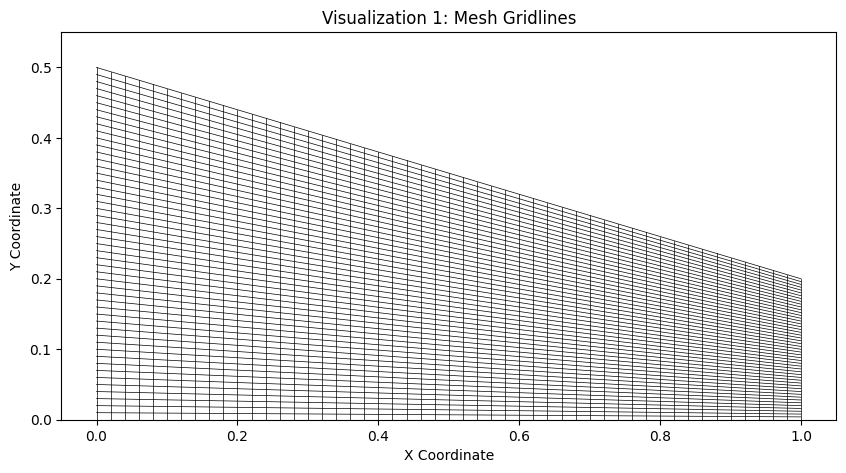

In [4]:
print("Displaying Figure 1: Mesh Gridlines")
fig1, ax1 = plt.subplots(figsize=(10, 6))

# Matplotlib's plot() function is smart:
# - plot(X, Y) plots all columns of X against all columns of Y.
# - plot(X.T, Y.T) plots all rows (transposed to be columns)

# Plot the "vertical" mesh lines (columns)
ax1.plot(X, Y, color='black', lw=0.5)
# Plot the "horizontal" mesh lines (rows)
ax1.plot(X.T, Y.T, color='black', lw=0.5)

# Set plot properties
ax1.set_title('Visualization 1: Mesh Gridlines')
ax1.set_xlabel('X Coordinate')
ax1.set_ylabel('Y Coordinate')
# Using 'equal' aspect ratio is crucial for seeing the mesh's true shape
ax1.set_aspect('equal')
ax1.set_ylim(0, np.max(Y) * 1.1) # Add some padding

# Coordinate class

In [5]:
class Coordinate2D():
    def __init__(self, x, y):
        self.x = x
        self.y = y

def calculate_area(ul, bl, br, ur):
    # calculate the area of the cell
    # ul (upper left), bl (bottom left), br (bottom right), ur (upper right) are the coordinates of the four vertices of the cell
    # apply Gaussian trapezoidal formula to calculate the areas
    area = 0.5 * ((ur.x * br.y - br.x * ur.y) + (br.x * bl.y - bl.x * br.y) + 
                  (bl.x * ul.y - ul.x * bl.y) + (ul.x * ur.y - ur.x * ul.y))
    return area

def dy(a, b):
    # Calculate distance between 'a' and 'b' along the y axis
    return b.y - a.y
    
def dx(a, b):
    # Calculate distance between 'a' and 'b' along the x axis
    return b.x - a.x
    
def dist(a, b):
    # Calculate the euclidean distance between 'a' and 'b'
    return np.sqrt((b.x - a.x)**2 + (b.y - a.y)**2)

def index(i, j):
    # Return the index in the computational vector based on the physical indices 'i', 'j' and dimX (global parameter)
    return i * dimX + j # Might be wrong
    

# Steady state solver

In [6]:
class SteadyHeat2D_FVM():
    def __init__(self, X, Y, boundary=[], TD=[], q=0.0, alpha=0.0, Tinf=0.0):
        # i, j is the index of the cell
        # X, Y is the mesh
        # boundary is the boundary condition: "R", "D", "N"
        # TD is the Dirichlet Temperature
        # q is the heat flux
        # alpha is the heat transfer coefficient
        # Tinf is the temperature of the surrounding

        self.X = X
        self.Y = Y
        self.boundary = boundary
        self.TD = TD
        self.q = q
        self.alpha = alpha
        self.Tinf = Tinf

        # n is the number of points in the first direction
        # m is the number of points in the second direction
        self.m, self.n = X.shape
        # m -> y or i , n -> x or j

        self.A = np.ones((self.n*self.m, self.n*self.m))
        self.B = np.ones(self.n*self.m)
        
    def set_stencil(self, i, j):
        # Based on 'i','j' decide if the node is inner or boundary (which boundary?)
        if (i < (self.m - 1)) and (j < (self.n - 1)) and (i > 0) and (j > 0):
            a, b = self.build_inner(i, j)
        elif (i == (self.m - 1)) and (j > 0) and (j < (self.n - 1)):
            a, b = self.build_south(i, j)
        elif (i == 0) and (j > 0) and (j < (self.n - 1)):
            a, b = self.build_north(i, j)
        elif (j == (self.n - 1)) and (i > 0) and (i < (self.m - 1)):
            a, b = self.build_east(i, j)
        elif (j == 0) and (i > 0) and (i < (self.m - 1)):
            a, b = self.build_west(i, j)
        elif (j == (self.n - 1)) and (i == (self.m - 1)):
            a, b = self.build_SE(i, j)
        elif (j == 0) and (i == (self.m - 1)):
            a, b = self.build_SW(i, j)
        elif (j == (self.n - 1)) and (i == 0):
            a, b = self.build_NE(i, j)
        elif (j == 0) and (i == 0):
            a, b = self.build_NW(i, j)
        return a, b  

    def build_inner(self, i, j):
        stencil = np.zeros(self.n*self.m)
        b = 0.0
        # % Nomenclature:
        # %
        # %    NW(i-1,j-1)   Nw -  N(i-1,j) -  Ne     NE(i-1,j+1)
        # %
        # %                 |                 |
        # %
        # %       nW - - - - nw ------ n ------ ne - - - nE
        # %                 |                 |
        # %       |         |        |        |       |
        # %                 |                 |
        # %   W(i, j-1) - - w - - P (i,j) - - e - -  E (i,j+1)
        # %                 |                 |
        # %       |         |        |        |       |
        # %                 |                 |
        # %      sW - - - - sw ------ s ------ se - - - sE
        # %
        # %                 |                 |
        # %
        # %   SW(i+1,j-1)   Sw  -  S(i+1,j)  - Se      SE(i+1,j+1)
        # %
        # % Indexing of stencil: 

        # %    D_4 - D_1 - D2
        # %     |     |     | 
        # %    D_3 - D_0 - D3
        # %     |     |     | 
        # %    D_2 -  D1 - D4
        
        # First coordinate is in the real x direction, and the second in the y direction, however 
        # changing the index i (first one) changes the point up or down and the j (second one) left and right
        
        # principle node coordinate
        P = Coordinate2D(self.X[i, j], self.Y[i, j])
        N = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
        S = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
        W = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
        E = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
        NW = Coordinate2D(self.X[i-1, j-1], self.Y[i-1, j-1])
        NE = Coordinate2D(self.X[i-1, j+1], self.Y[i-1, j+1])
        SW = Coordinate2D(self.X[i+1, j-1], self.Y[i+1, j-1])
        SE = Coordinate2D(self.X[i+1, j+1], self.Y[i+1, j+1])

        # auxiliary node coordinate
        Nw = Coordinate2D((N.x + NW.x)/2, (N.y + NW.y)/2)
        Ne = Coordinate2D((N.x + NE.x)/2, (N.y + NE.y)/2)
        Sw = Coordinate2D((S.x + SW.x)/2, (S.y + SW.y)/2)
        Se = Coordinate2D((S.x + SE.x)/2, (S.y + SE.y)/2)
        nW = Coordinate2D((W.x + NW.x)/2, (W.y + NW.y)/2)
        nE = Coordinate2D((E.x + NE.x)/2, (E.y + NE.y)/2)
        sW = Coordinate2D((W.x + SW.x)/2, (W.y + SW.y)/2)
        sE = Coordinate2D((E.x + SE.x)/2, (E.y + SE.y)/2)

        n = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)
        s = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
        w = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
        e = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)

        se = Coordinate2D((Se.x + e.x)/2, (Se.y + e.y)/2)
        sw = Coordinate2D((Sw.x + w.x)/2, (Sw.y + w.y)/2)
        ne = Coordinate2D((Ne.x + e.x)/2, (Ne.y + e.y)/2)
        nw = Coordinate2D((Nw.x + w.x)/2, (Nw.y + w.y)/2)
        
        # calculate the area of the cell
        S_P = calculate_area(ne, se, sw, nw)
        S_n = calculate_area(Ne, e, w, Nw)
        S_s = calculate_area(e, Se, Sw, w)
        S_w = calculate_area(n, s, sW, nW)
        S_e = calculate_area(nE, sE, s, n)

        D3 = ((dx(se, ne) * (dx(nE, n)/4 + dx(s, sE)/4 + dx(sE, nE))) / S_e + 
             (dy(se, ne) * (dy(nE, n)/4 + dy(s, sE)/4 + dy(sE, nE))) / S_e + 
             (dx(e, Ne) * dx(ne, nw)) / (4*S_n) + (dx(Se,e) * dx(sw,se)) / (4*S_s) + 
             (dy(e, Ne) * dy(ne, nw)) / (4*S_n) + (dy(Se,e) * dy(sw,se)) / (4*S_s)) / S_P
        D_3 = ((dx(nw, sw) * (dx(n, nW) / 4 + dx(sW, s) / 4 + dx(nW, sW))) / S_w +
              (dy(nw, sw) * (dy(n, nW) / 4 + dy(sW, s) / 4 + dy(nW, sW))) / S_w +
              (dx(Nw, w) * dx(ne, nw)) / (4 * S_n) +
              (dx(w, Sw) * dx(sw, se)) / (4 * S_s) +
              (dy(Nw, w) * dy(ne, nw)) / (4 * S_n) +
              (dy(w, Sw) * dy(sw, se)) / (4 * S_s)) / S_P
        D1 = ((dx(sw, se) * (dx(Se, e) / 4 + dx(w, Sw) / 4 + dx(Sw, Se))) / S_s +
            (dy(sw, se) * (dy(Se, e) / 4 + dy(w, Sw) / 4 + dy(Sw, Se))) / S_s +
            (dx(s, sE) * dx(se, ne)) / (4 * S_e) +
            (dx(sW, s) * dx(nw, sw)) / (4 * S_w) +
            (dy(s, sE) * dy(se, ne)) / (4 * S_e) +
            (dy(sW, s) * dy(nw, sw)) / (4 * S_w)) / S_P
        # North
        D_1 = ((dx(ne, nw) * (dx(e, Ne) / 4 + dx(Nw, w) / 4 + dx(Ne, Nw))) / S_n +
            (dy(ne, nw) * (dy(e, Ne) / 4 + dy(Nw, w) / 4 + dy(Ne, Nw))) / S_n +
            (dx(nE, n) * dx(se, ne)) / (4 * S_e) +
            (dx(n, nW) * dx(nw, sw)) / (4 * S_w) +
            (dy(nE, n) * dy(se, ne)) / (4 * S_e) +
            (dy(n, nW) * dy(nw, sw)) / (4 * S_w)) / S_P

        # NW
        D_4 = ((dx(Nw, w) * dx(ne, nw)) / (4 * S_n) +
            (dx(n, nW) * dx(nw, sw)) / (4 * S_w) +
            (dy(Nw, w) * dy(ne, nw)) / (4 * S_n) +
            (dy(n, nW) * dy(nw, sw)) / (4 * S_w)) / S_P

        # NE
        D2 = ((dx(nE, n) * dx(se, ne)) / (4 * S_e) +
            (dx(e, Ne) * dx(ne, nw)) / (4 * S_n) +
            (dy(nE, n) * dy(se, ne)) / (4 * S_e) +
            (dy(e, Ne) * dy(ne, nw)) / (4 * S_n)) / S_P

        # SW
        D_2 = ((dx(w, Sw) * dx(sw, se)) / (4 * S_s) +
            (dx(sW, s) * dx(nw, sw)) / (4 * S_w) +
            (dy(w, Sw) * dy(sw, se)) / (4 * S_s) +
            (dy(sW, s) * dy(nw, sw)) / (4 * S_w)) / S_P

        # SE
        D4 = ((dx(s, sE) * dx(se, ne)) / (4 * S_e) +
            (dx(Se, e) * dx(sw, se)) / (4 * S_s) +
            (dy(s, sE) * dy(se, ne)) / (4 * S_e) +
            (dy(Se, e) * dy(sw, se)) / (4 * S_s)) / S_P

        # Center (P)
        D0 = ((dx(se, ne) * (dx(n, s) + dx(nE, n) / 4 + dx(s, sE) / 4)) / S_e +
            (dx(ne, nw) * (dx(w, e) + dx(e, Ne) / 4 + dx(Nw, w) / 4)) / S_n +
            (dx(sw, se) * (dx(e, w) + dx(Se, e) / 4 + dx(w, Sw) / 4)) / S_s +
            (dx(nw, sw) * (dx(s, n) + dx(n, nW) / 4 + dx(sW, s) / 4)) / S_w +
            (dy(se, ne) * (dy(n, s) + dy(nE, n) / 4 + dy(s, sE) / 4)) / S_e +
            (dy(ne, nw) * (dy(w, e) + dy(e, Ne) / 4 + dy(Nw, w) / 4)) / S_n +
            (dy(sw, se) * (dy(e, w) + dy(Se, e) / 4 + dy(w, Sw) / 4)) / S_s +
            (dy(nw, sw) * (dy(s, n) + dy(n, nW) / 4 + dy(sW, s) / 4)) / S_w) / S_P
        
        stencil[index(i, j)] = D0
        stencil[index(i-1, j)] = D_1
        stencil[index(i+1, j)] = D1
        stencil[index(i, j-1)] = D_3
        stencil[index(i, j+1)] = D3
        stencil[index(i-1, j-1)] = D_4
        stencil[index(i-1, j+1)] = D2
        stencil[index(i+1, j-1)] = D_2
        stencil[index(i+1, j+1)] = D4
        
        return stencil,b
        
    def build_north(self, i, j):
        stencil = np.zeros(self.n*self.m)
        b = 0.0
        if self.boundary[0] == 'D':
            stencil[index(i, j)] = 1.0
            b = self.TD[0]
        else: 
            # principle node coordinate
            P = Coordinate2D(self.X[i, j], self.Y[i, j])
            S = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
            W = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
            E = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
            SW = Coordinate2D(self.X[i+1, j-1], self.Y[i+1, j-1])
            SE = Coordinate2D(self.X[i+1, j+1], self.Y[i+1, j+1])

            # auxiliary node coordinate
            Sw = Coordinate2D((S.x + SW.x)/2, (S.y + SW.y)/2)
            Se = Coordinate2D((S.x + SE.x)/2, (S.y + SE.y)/2)
            sW = Coordinate2D((W.x + SW.x)/2, (W.y + SW.y)/2)
            sE = Coordinate2D((E.x + SE.x)/2, (E.y + SE.y)/2)

            s = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
            w = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
            e = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)

            se = Coordinate2D((Se.x + e.x)/2, (Se.y + e.y)/2)
            sw = Coordinate2D((Sw.x + w.x)/2, (Sw.y + w.y)/2)

            # calculate the area of the cell
            S_ss = calculate_area(e, se, sw, w)
            S_s = calculate_area(e, Se, Sw, w)
            S_ssw = calculate_area(P, s, sW, W)
            S_sse = calculate_area(E, sE, s, P)

            # East
            D3 = (dy(sw, se) * (dy(Se, e) / 4) / S_s + dx(sw, se) * (dx(Se, e) / 4) / S_s +
                dy(se, e) * (dy(s, sE) / 4 + 3 * dy(sE, E) / 4 + dy(E, P) / 2) / S_sse +
                dx(se, e) * (dx(s, sE) / 4 + 3 * dx(sE, E) / 4 + dx(E, P) / 2) / S_sse) / S_ss

            # West
            D_3 = (dy(w, sw) * (3 * dy(W, sW) / 4 + dy(sW, s) / 4 + dy(P, W) / 2) / S_ssw +
                dx(w, sw) * (3 * dx(W, sW) / 4 + dx(sW, s) / 4 + dx(P, W) / 2) / S_ssw +
                dy(sw, se) * (dy(w, Sw) / 4) / S_s + dx(sw, se) * (dx(w, Sw) / 4) / S_s) / S_ss

            # South
            D1 = (dy(w, sw) * (dy(sW, s) / 4 + dy(s, P) / 4) / S_ssw +
                dx(w, sw) * (dx(sW, s) / 4 + dx(s, P) / 4) / S_ssw +
                dy(sw, se) * (dy(w, Sw) / 4 + dy(Sw, Se) + dy(Se, e) / 4) / S_s +
                dx(sw, se) * (dx(w, Sw) / 4 + dx(Sw, Se) + dx(Se, e) / 4) / S_s +
                dy(se, e) * (dy(P, s) / 4 + dy(s, sE) / 4) / S_sse +
                dx(se, e) * (dx(P, s) / 4 + dx(s, sE) / 4) / S_sse) / S_ss

            # SW
            D_2 = (dy(w, sw) * (dy(W, sW) / 4 + dy(sW, s) / 4) / S_ssw +
                dx(w, sw) * (dx(W, sW) / 4 + dx(sW, s) / 4) / S_ssw +
                dy(sw, se) * (dy(w, Sw) / 4) / S_s + dx(sw, se) * (dx(w, Sw) / 4) / S_s) / S_ss

            # SE
            D4 = (dy(sw, se) * (dy(Se, e) / 4) / S_s + dx(sw, se) * (dx(Se, e) / 4) / S_s +
                dy(se, e) * (dy(s, sE) / 4 + dy(sE, E) / 4) / S_sse +
                dx(se, e) * (dx(s, sE) / 4 + dx(sE, E) / 4) / S_sse) / S_ss
            
            coefficient = 0.0
            if self.boundary[0] == 'N':
                coefficient = 0.0
                b = self.q * dist(e, w) / S_ss
            elif self.boundary[0] == 'R':
                coefficient = - self.alpha
                b = - self.alpha * self.Tinf * dist(e, w) / S_ss
            else:
                raise ValueError('Unknown boundary type: %s' % boundary[0])
            
            D0 = (coefficient * dist(e, w) +
                dy(w, sw) * (dy(sW, s) / 4 + 3 * dy(s, P) / 4 + dy(P, W) / 2) / S_ssw +
                dx(w, sw) * (dx(sW, s) / 4 + 3 * dx(s, P) / 4 + dx(P, W) / 2) / S_ssw +
                dy(sw, se) * (dy(w, Sw) / 4 + dy(Se, e) / 4 + dy(e, w)) / S_s +
                dx(sw, se) * (dx(w, Sw) / 4 + dx(Se, e) / 4 + dx(e, w)) / S_s +
                dy(se, e) * (3 * dy(P, s) / 4 + dy(s, sE) / 4 + dy(E, P) / 2) / S_sse +
                dx(se, e) * (3 * dx(P, s) / 4 + dx(s, sE) / 4 + dx(E, P) / 2) / S_sse) / S_ss
            
            stencil[index(i, j)] = D0
            stencil[index(i+1, j)] = D1
            stencil[index(i, j-1)] = D_3
            stencil[index(i, j+1)] = D3
            stencil[index(i+1, j-1)] = D_2
            stencil[index(i+1, j+1)] = D4

        return stencil,b
    
    def build_south(self, i, j):
        stencil = np.zeros(self.n*self.m)
        b = 0.0
        if self.boundary[1] == 'D':
            stencil[index(i, j)] = 1.0
            b = self.TD[1]
        else: 
            # principle node coordinate
            P = Coordinate2D(self.X[i, j], self.Y[i, j])
            N = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
            W = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
            E = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
            NW = Coordinate2D(self.X[i-1, j-1], self.Y[i-1, j-1])
            NE = Coordinate2D(self.X[i-1, j+1], self.Y[i-1, j+1])

            # auxiliary node coordinate
            Nw = Coordinate2D((N.x + NW.x)/2, (N.y + NW.y)/2)
            Ne = Coordinate2D((N.x + NE.x)/2, (N.y + NE.y)/2)
            nW = Coordinate2D((W.x + NW.x)/2, (W.y + NW.y)/2)
            nE = Coordinate2D((E.x + NE.x)/2, (E.y + NE.y)/2)

            n = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)
            w = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
            e = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)

            ne = Coordinate2D((Ne.x + e.x)/2, (Ne.y + e.y)/2)
            nw = Coordinate2D((Nw.x + w.x)/2, (Nw.y + w.y)/2)

            # calculate the area of the cell
            N_nn = calculate_area(e, ne, nw, w)
            N_n = calculate_area(e, Ne, Nw, w)
            N_nnw = calculate_area(P, n, nW, W)
            N_nne = calculate_area(E, nE, n, P)

            # East
            D3 = (dy(nw, ne) * (dy(Ne, e) / 4) / N_n + dx(nw, ne) * (dx(Ne, e) / 4) / N_n +
                dy(ne, e) * (dy(n, nE) / 4 + 3 * dy(nE, E) / 4 + dy(E, P) / 2) / N_nne +
                dx(ne, e) * (dx(n, nE) / 4 + 3 * dx(nE, E) / 4 + dx(E, P) / 2) / N_nne) / N_nn

            # West
            D_3 = (dy(w, nw) * (3 * dy(W, nW) / 4 + dy(nW, n) / 4 + dy(P, W) / 2) / N_nnw +
                dx(w, nw) * (3 * dx(W, nW) / 4 + dx(nW, n) / 4 + dx(P, W) / 2) / N_nnw +
                dy(nw, ne) * (dy(w, Nw) / 4) / N_n + dx(nw, ne) * (dx(w, Nw) / 4) / N_n) / N_nn

            # North
            D_1 = (dy(w, nw) * (dy(nW, n) / 4 + dy(n, P) / 4) / N_nnw +
                dx(w, nw) * (dx(nW, n) / 4 + dx(n, P) / 4) / N_nnw +
                dy(nw, ne) * (dy(w, Nw) / 4 + dy(Nw, Ne) + dy(Ne, e) / 4) / N_n +
                dx(nw, ne) * (dx(w, Nw) / 4 + dx(Nw, Ne) + dx(Ne, e) / 4) / N_n +
                dy(ne, e) * (dy(P, n) / 4 + dy(n, nE) / 4) / N_nne +
                dx(ne, e) * (dx(P, n) / 4 + dx(n, nE) / 4) / N_nne) / N_nn

            # NW
            D2 = (dy(w, nw) * (dy(W, nW) / 4 + dy(nW, n) / 4) / N_nnw +
                dx(w, nw) * (dx(W, nW) / 4 + dx(nW, n) / 4) / N_nnw +
                dy(nw, ne) * (dy(w, Nw) / 4) / N_n + dx(nw, ne) * (dx(w, Nw) / 4) / N_n) / N_nn

            # NE
            D_4 = (dy(nw, ne) * (dy(Ne, e) / 4) / N_n + dx(nw, ne) * (dx(Ne, e) / 4) / N_n +
                dy(ne, e) * (dy(n, nE) / 4 + dy(nE, E) / 4) / N_nne +
                dx(ne, e) * (dx(n, nE) / 4 + dx(nE, E) / 4) / N_nne) / N_nn
            
            coefficient = 0.0
            if self.boundary[1] == 'N':
                coefficient = 0.0
                b = self.q * dist(e, w) / N_nn
            elif self.boundary[1] == 'R':
                coefficient = - self.alpha
                b = - self.alpha * self.Tinf * dist(e, w) / N_nn
            else:
                raise ValueError('Unknown boundary type: %s' % boundary[0])
            
            D0 = (coefficient * dist(e, w) +
                dy(w, nw) * (dy(nW, n) / 4 + 3 * dy(n, P) / 4 + dy(P, W) / 2) / N_nnw +
                dx(w, nw) * (dx(nW, n) / 4 + 3 * dx(n, P) / 4 + dx(P, W) / 2) / N_nnw +
                dy(nw, ne) * (dy(w, Nw) / 4 + dy(Ne, e) / 4 + dy(e, w)) / N_n +
                dx(nw, ne) * (dx(w, Nw) / 4 + dx(Ne, e) / 4 + dx(e, w)) / N_n +
                dy(ne, e) * (3 * dy(P, n) / 4 + dy(n, nE) / 4 + dy(E, P) / 2) / N_nne +
                dx(ne, e) * (3 * dx(P, n) / 4 + dx(n, nE) / 4 + dx(E, P) / 2) / N_nne) / N_nn
            
            stencil[index(i, j)] = D0
            stencil[index(i-1, j)] = D_1
            stencil[index(i, j-1)] = D_3
            stencil[index(i, j+1)] = D3
            stencil[index(i-1, j-1)] = D2
            stencil[index(i-1, j+1)] = D_4

        return stencil,b
         
    def build_east(self, i, j):
        stencil = np.zeros(self.n*self.m)
        b = 0.0
        if self.boundary[3] == 'D':
            stencil[index(i, j)] = 1.0
            b = self.TD[3]
        else: 
            # principle node coordinate
            P = Coordinate2D(self.X[i, j], self.Y[i, j])
            S = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
            W = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
            N = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
            SW = Coordinate2D(self.X[i+1, j-1], self.Y[i+1, j-1])
            NW = Coordinate2D(self.X[i-1, j-1], self.Y[i-1, j-1])

            # auxiliary node coordinate
            Sw = Coordinate2D((S.x + SW.x)/2, (S.y + SW.y)/2)
            Nw = Coordinate2D((N.x + NW.x)/2, (N.y + NW.y)/2)
            sW = Coordinate2D((W.x + SW.x)/2, (W.y + SW.y)/2)
            nW = Coordinate2D((W.x + NW.x)/2, (W.y + NW.y)/2)

            s = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
            w = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
            n = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)

            nw = Coordinate2D((nW.x + n.x)/2, (nW.y + n.y)/2)
            sw = Coordinate2D((sW.x + s.x)/2, (sW.y + s.y)/2)

            # calculate the area of the cell
            S_ee = calculate_area(s, sw, nw, n)
            S_e = calculate_area(s, sW, nW, n)
            S_ees = calculate_area(S, Sw, w, P)
            S_een = calculate_area(N, P, w, Nw)

            # North
            D_1 = (dy(nw, sw) * (dy(n, nW) / 4) / S_e + dx(nw, sw) * (dx(n, nW) / 4) / S_e +
                dy(n, nw) * (dy(Nw, w) / 4 + 3 * dy(N, Nw) / 4 + dy(P, N) / 2) / S_een +
                dx(n, nw) * (dx(Nw, w) / 4 + 3 * dx(N, Nw) / 4 + dx(P, N) / 2) / S_een) / S_ee
            
            # South 
            D1 = (dy(nw, sw) * (dy(sW, s) / 4) / S_e + dx(nw, sw) * (dx(sW, s) / 4) / S_e +
                dy(sw, s) * (dy(w, Sw) / 4 + 3 * dy(Sw, S) / 4 + dy(S, P) / 2) / S_ees +
                dx(sw, s) * (dx(w, Sw) / 4 + 3 * dx(Sw, S) / 4 + dx(S, P) / 2) / S_ees) / S_ee

            # West
            D_3 = (dy(sw, s) * (dy(w, Sw) / 4 + dy(P, w) / 4) / S_ees +
                dx(sw, s) * (dx(w, Sw) / 4 + dx(P, w) / 4) / S_ees +
                dy(nw, sw) * (dy(sW, s) / 4 + dy(nW, sW) + dy(n, nW) / 4) / S_e +
                dx(nw, sw) * (dx(sW, s) / 4 + dx(nW, sW) + dx(n, nW) / 4) / S_e +
                dy(n, nw) * (dy(w, P) / 4 + dy(Nw, w) / 4) / S_een +
                dx(n, nw) * (dx(w, P) / 4 + dx(Nw, w) / 4) / S_een) / S_ee

            # NW
            D_4 = (dy(n, nw) * (dy(N, Nw) / 4 + dy(Nw, w) / 4) / S_een +
                dx(n, nw) * (dx(N, Nw) / 4 + dx(Nw, w) / 4) / S_een +
                dy(nw, sw) * (dy(n, nW) / 4) / S_e + dx(nw, sw) * (dx(n, nW) / 4) / S_e) / S_ee

            # SW
            D_2 = (dy(nw, sw) * (dy(sW, s) / 4) / S_e + dx(nw, sw) * (dx(sW, s) / 4) / S_e +
                dy(sw, s) * (dy(Sw, S) / 4 + dy(w, Sw) / 4) / S_ees +
                dx(sw, s) * (dx(Sw, S) / 4 + dx(w, Sw) / 4) / S_ees) / S_ee
            
            coefficient = 0.0
            if self.boundary[3] == 'N':
                coefficient = 0.0
                b = self.q * dist(n, s) / S_ee
            elif self.boundary[3] == 'R':
                coefficient = - self.alpha
                b = - self.alpha * self.Tinf * dist(n, s) / S_ee
            else:
                raise ValueError('Unknown boundary type: %s' % boundary[0])
            
            # calculate the area of the cell
            S_ee = calculate_area(s, sw, nw, n)
            S_e = calculate_area(s, sW, nW, n)
            S_ees = calculate_area(S, Sw, w, P)
            S_een = calculate_area(N, P, w, Nw)
            # w->s, e->n,
            D0 = (coefficient * dist(nw, sw) +
                dy(sw, s) * (dy(w, Sw) / 4 + 3 * dy(P, w) / 4 + dy(S, P) / 2) / S_ees +
                dx(sw, s) * (dx(w, Sw) / 4 + 3 * dx(P, w) / 4 + dx(S, P) / 2) / S_ees +
                dy(nw, sw) * (dy(sW, s) / 4 + dy(n, nW) / 4 + dy(s, n)) / S_e +
                dx(nw, sw) * (dx(sW, s) / 4 + dx(n, nW) / 4 + dx(s, n)) / S_e +
                dy(n, nw) * (3 * dy(w, P) / 4 + dy(Nw, w) / 4 + dy(P, N) / 2) / S_een +
                dx(n, nw) * (3 * dx(w, P) / 4 + dx(Nw, w) / 4 + dx(P, N) / 2) / S_een) / S_ee

            stencil[index(i, j)] = D0
            stencil[index(i-1, j)] = D_1
            stencil[index(i+1, j)] = D1
            stencil[index(i, j-1)] = D_3
            stencil[index(i-1, j-1)] = D_4
            stencil[index(i+1, j-1)] = D_2

        return stencil,b        
    
    def build_west(self, i, j):
        stencil = np.zeros(self.n*self.m)
        b = 0.0
        if self.boundary[2] == 'D':  # Using index 2 for west boundary
            stencil[index(i, j)] = 1.0
            b = self.TD[2]
        else: 
            # principle node coordinate
            P = Coordinate2D(self.X[i, j], self.Y[i, j])
            S = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
            N = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
            E = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
            SE = Coordinate2D(self.X[i+1, j+1], self.Y[i+1, j+1])
            NE = Coordinate2D(self.X[i-1, j+1], self.Y[i-1, j+1])

            # auxiliary node coordinate
            Se = Coordinate2D((S.x + SE.x)/2, (S.y + SE.y)/2)
            Ne = Coordinate2D((N.x + NE.x)/2, (N.y + NE.y)/2)
            sE = Coordinate2D((E.x + SE.x)/2, (E.y + SE.y)/2)
            nE = Coordinate2D((E.x + NE.x)/2, (E.y + NE.y)/2)

            s = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
            n = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)
            e = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)

            ne = Coordinate2D((Ne.x + e.x)/2, (Ne.y + e.y)/2)
            se = Coordinate2D((Se.x + e.x)/2, (Se.y + e.y)/2)

            # calculate the area of the cell
            S_ww = calculate_area(s, n, ne, se)
            S_w = calculate_area(s, n, nE, sE)
            S_wws = calculate_area(S, P, e, Se)
            S_wwn = calculate_area(P, N, Ne, e)

            # North
            D_1 = (dy(se, ne) * (dy(nE, n) / 4) / S_w + dx(se, ne) * (dx(nE, n) / 4) / S_w +
                dy(ne, n) * (dy(e, Ne) / 4 + 3 * dy(Ne, N) / 4 + dy(N, P) / 2) / S_wwn +
                dx(ne, n) * (dx(e, Ne) / 4 + 3 * dx(Ne, N) / 4 + dx(N, P) / 2) / S_wwn) / S_ww

            # South
            D1 = (dy(se, ne) * (dy(s, sE) / 4) / S_w + dx(se, ne) * (dx(s, sE) / 4) / S_w +
                dy(s, se) * (dy(e, Se) / 4 + 3 * dy(Se, S) / 4 + dy(S, P) / 2) / S_wws +
                dx(s, se) * (dx(e, Se) / 4 + 3 * dx(Se, S) / 4 + dx(S, P) / 2) / S_wws) / S_ww

            # East
            D3 = (dy(s, se) * (dy(Se, e) / 4 + dy(e, P) / 4) / S_wws +
                dx(s, se) * (dx(Se, e) / 4 + dx(e, P) / 4) / S_wws +
                dy(se, ne) * (dy(s, sE) / 4 + dy(sE, nE) + dy(nE, n) / 4) / S_w +
                dx(se, ne) * (dx(s, sE) / 4 + dx(sE, nE) + dx(nE, n) / 4) / S_w +
                dy(ne, n) * (dy(P, e) / 4 + dy(e, Ne) / 4) / S_wwn +
                dx(ne, n) * (dx(P, e) / 4 + dx(e, Ne) / 4) / S_wwn) / S_ww

            # NE
            D2 = (dy(ne, n) * (dy(e, Ne) / 4 + dy(Ne, N) / 4) / S_wwn +
                dx(ne, n) * (dx(e, Ne) / 4 + dx(Ne, N) / 4) / S_wwn +
                dy(se, ne) * (dy(nE, n) / 4) / S_w + dx(se, ne) * (dx(nE, n) / 4) / S_w) / S_ww

            # SE
            D4 = (dy(se, ne) * (dy(s, sE) / 4) / S_w + dx(se, ne) * (dx(s, sE) / 4) / S_w +
                dy(s, se) * (dy(Se, e) / 4 + dy(Se, e) / 4) / S_wws +
                dx(s, se) * (dx(Se, e) / 4 + dx(Se, e) / 4) / S_wws) / S_ww
            
            coefficient = 0.0
            if self.boundary[2] == 'N':
                coefficient = 0.0
                b = self.q * dist(n, s) / S_ww
            elif self.boundary[2] == 'R':
                coefficient = - self.alpha
                b = - self.alpha * self.Tinf * dist(n, s) / S_ww
            else:
                raise ValueError('Unknown boundary type: %s' % self.boundary[3])
            
            D0 = (coefficient * dist(ne, se) +
                dy(s, se) * (dy(Se, e) / 4 + 3 * dy(e, P) / 4 + dy(P, S) / 2) / S_wws +
                dx(s, se) * (dx(Se, e) / 4 + 3 * dx(e, P) / 4 + dx(P, S) / 2) / S_wws +
                dy(se, ne) * (dy(s, sE) / 4 + dy(nE, n) / 4 + dy(n, s)) / S_w +
                dx(se, ne) * (dx(s, sE) / 4 + dx(nE, n) / 4 + dx(n, s)) / S_w +
                dy(ne, n) * (3 * dy(P, e) / 4 + dy(e, Ne) / 4 + dy(N, P) / 2) / S_wwn +
                dx(ne, n) * (3 * dx(P, e) / 4 + dx(e, Ne) / 4 + dx(N, P) / 2) / S_wwn) / S_ww
            
            stencil[index(i, j)] = D0
            stencil[index(i-1, j)] = D_1
            stencil[index(i+1, j)] = D1
            stencil[index(i, j+1)] = D3
            stencil[index(i-1, j+1)] = D2
            stencil[index(i+1, j+1)] = D4

        return stencil,b
           
    def build_NW(self, i, j):
        stencil = np.zeros(self.n*self.m)
        b = 0.0
        
        # For NW corner, we need to consider both North and West boundary conditions
        if self.boundary[0] == 'D' or self.boundary[2] == 'D':  # If either boundary is Dirichlet
            stencil[index(i, j)] = 1.0
            b = self.TD[0] if self.boundary[0] == 'D' else self.TD[2]
        else:
            # principle node coordinates
            P = Coordinate2D(self.X[i, j], self.Y[i, j])
            S = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
            E = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
            SE = Coordinate2D(self.X[i+1, j+1], self.Y[i+1, j+1])

            # auxiliary node coordinates (Mirrored from NE)
            Se = Coordinate2D((S.x + SE.x)/2, (S.y + SE.y)/2)
            sE = Coordinate2D((E.x + SE.x)/2, (E.y + SE.y)/2)
            s = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
            e = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)
            
            # --- Consistent se definition (Mirrored from NE's sw) ---
            se = Coordinate2D((sE.x + s.x)/2, (sE.y + s.y)/2)

            # calculate areas (Mirrored from NE)
            S_nw = calculate_area(e, se, s, P) # Main CV (Mirrored from NE's corrected S_ne)
            S_nws = calculate_area(P, e, Se, S) # South sub-volume
            S_nwe = calculate_area(P, E, sE, s) # East sub-volume

            # --- D1 (South) coefficient (Mirrored from NE's D1) ---
            D1 = (dy(s, se) * (dy(Se, e) / 4 + 3 * dy(S, Se) / 4 + dy(P, S) / 2) / S_nws +
                  dx(s, se) * (dx(Se, e) / 4 + 3 * dx(S, Se) / 4 + dx(P, S) / 2) / S_nws +
                  dy(se, e) * (dy(s, sE) / 4 + dy(P, s) / 4) / S_nwe +
                  dx(se, e) * (dx(s, sE) / 4 + dx(P, s) / 4) / S_nwe
                 ) / S_nw

            # --- D3 (East) coefficient (Mirrored from NE's D_3) ---
            D3 = (dy(s, se) * (dy(e, Se) / 4 + dy(P, e) / 4) / S_nws +
                  dx(s, se) * (dx(e, Se) / 4 + dx(P, e) / 4) / S_nws +
                  dy(se, e) * (dy(s, sE) / 4 + 3 * dy(sE, E) / 4 + dy(E, P) / 2) / S_nwe +
                  dx(se, e) * (dx(s, sE) / 4 + 3 * dx(sE, E) / 4 + dx(E, P) / 2) / S_nwe
                 ) / S_nw

            # --- D4 (Southeast) coefficient (Mirrored from NE's D_2) ---
            D4 = (dy(s, se) * (dy(Se, S) / 4 + dy(e, Se) / 4) / S_nws +
                  dx(s, se) * (dx(Se, S) / 4 + dx(e, Se) / 4) / S_nws +
                  dy(se, e) * (dy(s, sE) / 4 + dy(sE, E) / 4) / S_nwe +
                  dx(se, e) * (dx(s, sE) / 4 + dx(sE, E) / 4) / S_nwe
                 ) / S_nw

            # Calculate boundary contributions
            coef_n = 0.0
            coef_w = 0.0
            b_n = 0.0
            b_w = 0.0

            # North boundary contribution (face e-P)
            if self.boundary[0] == 'N':
                b_n = self.q * dist(e, P) / S_nw
            elif self.boundary[0] == 'R':
                coef_n = -self.alpha
                b_n = -self.alpha * self.Tinf * dist(e, P) / S_nw

            # West boundary contribution (face P-s)
            if self.boundary[2] == 'N':
                b_w = self.q * dist(P, s) / S_nw
            elif self.boundary[2] == 'R':
                coef_w = -self.alpha
                b_w = -self.alpha * self.Tinf * dist(P, s) / S_nw

            # --- D0 (Center) coefficient (Mirrored from NE's D0) ---
            D0 = ((coef_n * dist(e, P) + coef_w * dist(P, s)) +
                  dy(s, se) * (dy(Se, e) / 4 + 3 * dy(e, P) / 4 + dy(P, S) / 2) / S_nws +
                  dx(s, se) * (dx(Se, e) / 4 + 3 * dx(e, P) / 4 + dx(P, S) / 2) / S_nws +
                  dy(se, e) * (dy(s, sE) / 4 + 3 * dy(P, s) / 4 + dy(E, P) / 2) / S_nwe +
                  dx(se, e) * (dx(s, sE) / 4 + 3 * dx(P, s) / 4 + dx(E, P) / 2) / S_nwe
                 ) / S_nw

            b = b_n + b_w

            # Assemble the stencil
            stencil[index(i, j)] = D0
            stencil[index(i+1, j)] = D1
            stencil[index(i, j+1)] = D3
            stencil[index(i+1, j+1)] = D4

        return stencil, b
    
    def build_NE(self, i, j):
        stencil = np.zeros(self.n*self.m)
        b = 0.0
        
        # For NE corner, we need to consider both North and East boundary conditions
        if self.boundary[0] == 'D' or self.boundary[3] == 'D':  # If either boundary is Dirichlet
            stencil[index(i, j)] = 1.0
            b = self.TD[0] if self.boundary[0] == 'D' else self.TD[3]
        else:
            # principle node coordinates
            P = Coordinate2D(self.X[i, j], self.Y[i, j])
            S = Coordinate2D(self.X[i+1, j], self.Y[i+1, j])
            W = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
            SW = Coordinate2D(self.X[i+1, j-1], self.Y[i+1, j-1])

            # auxiliary node coordinates 
            Sw = Coordinate2D((S.x + SW.x)/2, (S.y + SW.y)/2)
            sW = Coordinate2D((W.x + SW.x)/2, (W.y + SW.y)/2)
            s = Coordinate2D((S.x + P.x)/2, (S.y + P.y)/2)
            w = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
            sw = Coordinate2D((sW.x + s.x)/2, (sW.y + s.y)/2)

            # calculate areas
            S_ne = calculate_area(w, P, s, sw) # Main CV
            S_nes = calculate_area(P, S, Sw, w) # South sub-volume
            S_new = calculate_area(P, s, sW, W) # West sub-volume

            # --- D1 (South) coefficient ---
            D1 = (dy(sw, s) * (dy(w, Sw) / 4 + 3 * dy(Sw, S) / 4 + dy(S, P) / 2) / S_nes +
                  dx(sw, s) * (dx(w, Sw) / 4 + 3 * dx(Sw, S) / 4 + dx(S, P) / 2) / S_nes +
                  dy(w, sw) * (dy(sW, s) / 4 + dy(s, P) / 4) / S_new +
                  dx(w, sw) * (dx(sW, s) / 4 + dx(s, P) / 4) / S_new
                 ) / S_ne

            # --- D_3 (West) coefficient ---
            D_3 = (dy(sw, s) * (dy(w, Sw) / 4 + dy(P, w) / 4) / S_nes +
                   dx(sw, s) * (dx(w, Sw) / 4 + dx(P, w) / 4) / S_nes +
                   dy(w, sw) * (dy(sW, s) / 4 + 3 * dy(W, sW) / 4 + dy(P, W) / 2) / S_new +
                   dx(w, sw) * (dx(sW, s) / 4 + 3 * dx(W, sW) / 4 + dx(P, W) / 2) / S_new
                  ) / S_ne

            # --- D_2 (Southwest) coefficient ---
            D_2 = (dy(sw, s) * (dy(Sw, S) / 4 + dy(w, Sw) / 4) / S_nes +
                   dx(sw, s) * (dx(Sw, S) / 4 + dx(w, Sw) / 4) / S_nes +
                   dy(w, sw) * (dy(sW, s) / 4 + dy(W, sW) / 4) / S_new +
                   dx(w, sw) * (dx(sW, s) / 4 + dx(W, sW) / 4) / S_new
                  ) / S_ne

            # Calculate boundary contributions 
            coef_n = 0.0
            coef_e = 0.0
            b_n = 0.0
            b_e = 0.0

            # North boundary contribution (face P-w)
            if self.boundary[0] == 'N':
                b_n = self.q * dist(P, w) / S_ne
            elif self.boundary[0] == 'R':
                coef_n = -self.alpha
                b_n = -self.alpha * self.Tinf * dist(P, w) / S_ne

            # East boundary contribution (face s-P)
            if self.boundary[3] == 'N':
                b_e = self.q * dist(s, P) / S_ne
            elif self.boundary[3] == 'R':
                coef_e = -self.alpha
                b_e = -self.alpha * self.Tinf * dist(s, P) / S_ne

            # --- D0 (Center) coefficient ---
            D0 = ((coef_n * dist(P, w) + coef_e * dist(s, P)) +
                  dy(sw, s) * (dy(w, Sw) / 4 + 3 * dy(P, w) / 4 + dy(S, P) / 2) / S_nes +
                  dx(sw, s) * (dx(w, Sw) / 4 + 3 * dx(P, w) / 4 + dx(S, P) / 2) / S_nes +
                  dy(w, sw) * (dy(sW, s) / 4 + 3 * dy(s, P) / 4 + dy(P, W) / 2) / S_new +
                  dx(w, sw) * (dx(sW, s) / 4 + 3 * dx(s, P) / 4 + dx(P, W) / 2) / S_new
                 ) / S_ne

            b = b_n + b_e

            # Assemble the stencil (These were correct)
            stencil[index(i, j)] = D0
            stencil[index(i+1, j)] = D1
            stencil[index(i, j-1)] = D_3
            stencil[index(i+1, j-1)] = D_2

        return stencil, b
    
    def build_SW(self, i, j):
        stencil = np.zeros(self.n*self.m)
        b = 0.0
        
        # For SW corner, we need to consider both South and West boundary conditions
        if self.boundary[1] == 'D' or self.boundary[2] == 'D':  # If either boundary is Dirichlet
            stencil[index(i, j)] = 1.0
            b = self.TD[1] if self.boundary[1] == 'D' else self.TD[2]
        else:
            # principle node coordinates
            P = Coordinate2D(self.X[i, j], self.Y[i, j])
            N = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
            E = Coordinate2D(self.X[i, j+1], self.Y[i, j+1])
            NE = Coordinate2D(self.X[i-1, j+1], self.Y[i-1, j+1])

            # auxiliary node coordinates (Mirrored from SE)
            Ne = Coordinate2D((N.x + NE.x)/2, (N.y + NE.y)/2)
            nE = Coordinate2D((E.x + NE.x)/2, (E.y + NE.y)/2)
            n = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)
            e = Coordinate2D((E.x + P.x)/2, (E.y + P.y)/2)
            
            # --- Consistent ne definition (Mirrored from SE's nw) ---
            ne = Coordinate2D((nE.x + n.x)/2, (nE.y + n.y)/2)

            # calculate areas (Mirrored from SE)
            S_sw = calculate_area(P, n, ne, e) # Main CV
            S_swn = calculate_area(P, N, Ne, e) # North sub-volume
            S_swe = calculate_area(P, n, nE, R) # East sub-volume

            # --- D_1 (North) coefficient (Mirrored from SE's D_1) ---
            D_1 = (dy(e, ne) * (dy(nE, n) / 4 + dy(n, P) / 4) / S_swe + 
                   dx(e, ne) * (dx(nE, n) / 4 + dx(n, P) / 4) / S_swe +
                   dy(ne, n) * (dy(e, Ne) / 4 + 3 * dy(Ne, N) / 4 + dy(N, P) / 2) / S_swn +
                   dx(ne, n) * (dx(e, Ne) / 4 + 3 * dx(Ne, N) / 4 + dx(N, P) / 2) / S_swn
                  ) / S_sw

            # --- D3 (East) coefficient (Mirrored from SE's D_3) ---
            D3 = (dy(e, ne) * (dy(P, E) / 2 + 3 * dy(E, nE) / 4 + dy(nE, n) / 4) / S_swe + 
                  dx(e, ne) * (dx(P, E) / 2 + 3 * dx(E, nE) / 4 + dx(nE, n) / 4) / S_swe +
                  dy(ne, n) * (dy(P, e) / 4 + dy(e, Ne) / 4) / S_swn +
                  dx(ne, n) * (dx(P, e) / 4 + dx(e, Ne) / 4) / S_swn
                 ) / S_sw

            # --- D2 (Northeast) coefficient (Mirrored from SE's D_4) ---
            D2 = (dy(ne, n) * (dy(Ne, N) / 4 + dy(e, Ne) / 4) / S_swn +
                  dx(ne, n) * (dx(Ne, N) / 4 + dx(e, Ne) / 4) / S_swn +
                  dy(ne, e) * (dy(nE, n) / 4 + dy(E, nE) / 4) / S_swe +
                  dx(ne, e) * (dx(nE, n) / 4 + dx(E, nE) / 4) / S_swe
                 ) / S_sw

            # Calculate boundary contributions
            coef_s = 0.0
            coef_w = 0.0
            b_s = 0.0
            b_w = 0.0

            # South boundary contribution (face e-P)
            if self.boundary[1] == 'N':
                b_s = self.q * dist(e, P) / S_sw
            elif self.boundary[1] == 'R':
                coef_s = -self.alpha
                b_s = -self.alpha * self.Tinf * dist(e, P) / S_sw

            # West boundary contribution (face P-n)
            if self.boundary[2] == 'N':
                b_w = self.q * dist(P, n) / S_sw
            elif self.boundary[2] == 'R':
                coef_w = -self.alpha
                b_w = -self.alpha * self.Tinf * dist(P, n) / S_sw

            # --- D0 (Center) coefficient (Mirrored from SE's D0) ---
            D0 = ((coef_s * dist(e, P) + coef_w * dist(P, n)) + # Boundary terms
                  dy(e, ne) * (dy(P, E) / 2 + dy(nE, n) / 4 + 3 * dy(n, P) / 4) / S_swe +
                  dx(e, ne) * (dx(P, E) / 2 + dx(nE, n) / 4 + 3 * dx(n, P) / 4) / S_swe +
                  dy(ne, n) * (3 * dy(P, e) / 4 + dy(e, Ne) / 4 + dy(N, P) / 2) / S_swn +
                  dx(ne, n) * (3 * dx(P, e) / 4 + dx(e, Ne) / 4 + dx(N, P) / 2) / S_swn
                 ) / S_sw

            b = b_s + b_w

            # Assemble the stencil
            stencil[index(i, j)] = D0
            stencil[index(i-1, j)] = D_1
            stencil[index(i, j+1)] = D3
            stencil[index(i-1, j+1)] = D2 # Corresponds to NE node

        return stencil, b
    
    def build_SE(self, i, j):
        stencil = np.zeros(self.n*self.m)
        b = 0.0
        
        # For SE corner, we need to consider both South and East boundary conditions
        if self.boundary[1] == 'D' or self.boundary[3] == 'D':  # If either boundary is Dirichlet
            stencil[index(i, j)] = 1.0
            # This logic might need a check if both are 'D'
            b = self.TD[1] if self.boundary[1] == 'D' else self.TD[3] 
        else:
            # principle node coordinates
            P = Coordinate2D(self.X[i, j], self.Y[i, j])
            N = Coordinate2D(self.X[i-1, j], self.Y[i-1, j])
            W = Coordinate2D(self.X[i, j-1], self.Y[i, j-1])
            NW = Coordinate2D(self.X[i-1, j-1], self.Y[i-1, j-1])

            # auxiliary node coordinates
            Nw = Coordinate2D((N.x + NW.x)/2, (N.y + NW.y)/2)
            nW = Coordinate2D((W.x + NW.x)/2, (W.y + NW.y)/2)
            n = Coordinate2D((N.x + P.x)/2, (N.y + P.y)/2)
            w = Coordinate2D((W.x + P.x)/2, (W.y + P.y)/2)
            
            # --- Consistent nw definition ---
            nw = Coordinate2D((nW.x + n.x)/2, (nW.y + n.y)/2)

            # calculate areas
            S_se = calculate_area(w, nw, n, P) # Main CV
            S_sen = calculate_area(N, P, w, Nw) # North sub-volume
            S_sew = calculate_area(P, W, nW, n) # West sub-volume (logic adapted from build_north S_ssw)
                                               # (build_east S_e definition was for a full cell)

            # --- D_1 (North) coefficient ---
            # (Flux from West face 'nw-w' + Flux from North face 'n-nw')
            D_1 = (dy(nw, w) * (dy(n, nW) / 4 + dy(P, n) / 4) / S_sew + 
                   dx(nw, w) * (dx(n, nW) / 4 + dx(P, n) / 4) / S_sew +
                   dy(n, nw) * (dy(Nw, w) / 4 + 3 * dy(N, Nw) / 4 + dy(P, N) / 2) / S_sen +
                   dx(n, nw) * (dx(Nw, w) / 4 + 3 * dx(N, Nw) / 4 + dx(P, N) / 2) / S_sen
                  ) / S_se

            # --- D_3 (West) coefficient ---
            # (Flux from West face 'nw-w' + Flux from North face 'n-nw')
            D_3 = (dy(nw, w) * (dy(W, P) / 2 + 3 * dy(nW, W) / 4 + dy(n, nW) / 4) / S_sew + 
                   dx(nw, w) * (dx(W, P) / 2 + 3 * dx(nW, W) / 4 + dx(n, nW) / 4) / S_sew +
                   dy(n, nw) * (dy(w, P) / 4 + dy(Nw, w) / 4) / S_sen +
                   dx(n, nw) * (dx(w, P) / 4 + dx(Nw, w) / 4) / S_sen
                  ) / S_se

            # --- D_4 (NW) coefficient ---
            # (Flux from West face 'nw-w' + Flux from North face 'n-nw')
            D_4 = (dy(n, nw) * (dy(N, Nw) / 4 + dy(Nw, w) / 4) / S_sen +
                   dx(n, nw) * (dx(N, Nw) / 4 + dx(Nw, w) / 4) / S_sen +
                   dy(nw, w) * (dy(n, nW) / 4 + dy(nW, W) / 4) / S_sew +
                   dx(nw, w) * (dx(n, nW) / 4 + dx(nW, W) / 4) / S_sew
                  ) / S_se

            # Calculate boundary contributions
            coef_s = 0.0
            coef_e = 0.0
            b_s = 0.0
            b_e = 0.0

            # South boundary contribution (face w-P)
            if self.boundary[1] == 'N':
                b_s = self.q * dist(w, P) / S_se
            elif self.boundary[1] == 'R':
                coef_s = -self.alpha
                b_s = -self.alpha * self.Tinf * dist(w, P) / S_se

            # East boundary contribution (face P-n)
            if self.boundary[3] == 'N':
                b_e = self.q * dist(P, n) / S_se
            elif self.boundary[3] == 'R':
                coef_e = -self.alpha
                b_e = -self.alpha * self.Tinf * dist(P, n) / S_se

            # --- D0 (Center) coefficient ---
            # (Boundary terms + Flux from West face 'nw-w' + Flux from North face 'n-nw')
            D0 = ((coef_s * dist(w, P) + coef_e * dist(P, n)) + # Boundary terms
                  dy(nw, w) * (dy(W, P) / 2 + dy(n, nW) / 4 + 3 * dy(P, n) / 4) / S_sew +
                  dx(nw, w) * (dx(W, P) / 2 + dx(n, nW) / 4 + 3 * dx(P, n) / 4) / S_sew +
                  dy(n, nw) * (3 * dy(w, P) / 4 + dy(Nw, w) / 4 + dy(P, N) / 2) / S_sen +
                  dx(n, nw) * (3 * dx(w, P) / 4 + dx(Nw, w) / 4 + dx(P, N) / 2) / S_sen
                 ) / S_se

            b = b_s + b_e

            # Assemble the stencil (This was correct)
            stencil[index(i, j)] = D0
            stencil[index(i-1, j)] = D_1
            stencil[index(i, j-1)] = D_3
            stencil[index(i-1, j-1)] = D_4

        return stencil, b
    
    def solve(self):
        for i in range(self.m):
            for j in range(self.n):
                # Set stencil for the node
                k = index(i, j)
                a, b = self.set_stencil(i, j)
                self.A[k, :] = a
                self.B[k] = b
        T = np.linalg.solve(self.A, self.B)        
        
        return T.reshape(dimY, dimX)
        
    def plot_Result(self, T, plot_type="both"):
        """
        Plot the temperature distribution in 2D, 3D, or both side by side
        Args:
            T: Temperature field (2D array)
            plot_type: "2D", "3D", or "both" for side-by-side plots
        """
        
        # Create a complete solution by mirroring across symmetry line
        T_complete = np.vstack((T, np.flipud(T)))
        X_complete = np.vstack((self.X, np.flipud(self.X)))
        Y_complete = np.vstack((self.Y, -np.flipud(self.Y)))
        
        if plot_type == "2D":
            plt.figure(figsize=(6, 4))
            # Create heatmap using pcolormesh for better control
            heatmap = plt.pcolormesh(X_complete, Y_complete, T_complete, 
                                cmap='hot', shading='auto')
            plt.colorbar(heatmap, label='Temperature')
            
            # Add contour lines for better visualization
            contours = plt.contour(X_complete, Y_complete, T_complete, 
                                colors='black', alpha=0.5, linewidths=0.5)
            plt.clabel(contours, inline=True, fontsize=8)
            
            plt.title('2D Temperature Distribution')
            plt.xlabel('X Coordinate')
            plt.ylabel('Y Coordinate')
            plt.axis('equal')
            plt.grid(True, linestyle='--', alpha=0.3)
            
        elif plot_type == "3D":
            fig = plt.figure(figsize=(6, 6))
            ax = fig.add_subplot(111, projection='3d')
            
            # Create surface plot
            surf = ax.plot_surface(X_complete, Y_complete, T_complete, 
                                cmap='hot', edgecolor='none')
            
            # Add contour plot at bottom of 3D plot
            offset = np.min(T_complete) - 0.1 * (np.max(T_complete) - np.min(T_complete))
            ax.contour(X_complete, Y_complete, T_complete, 
                    zdir='z', offset=offset, cmap='hot')
            
            # Add colorbar
            fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Temperature')
            
            ax.set_title('3D Temperature Distribution')
            ax.set_xlabel('X Coordinate')
            ax.set_ylabel('Y Coordinate')
            ax.set_zlabel('Temperature')
            
            # Set viewing angle for better visualization
            ax.view_init(elev=30, azim=-45)
        
        elif plot_type == "both":
            # Create a figure with two subplots side by side
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
            
            # 2D plot on left
            heatmap = ax1.pcolormesh(X_complete, Y_complete, T_complete, 
                                cmap='hot', shading='auto')
            plt.colorbar(heatmap, ax=ax1, label='Temperature')
            
            contours = ax1.contour(X_complete, Y_complete, T_complete, 
                                colors='black', alpha=0.5, linewidths=0.5)
            ax1.clabel(contours, inline=True, fontsize=8)
            
            ax1.set_title('2D Temperature Distribution')
            ax1.set_xlabel('X Coordinate')
            ax1.set_ylabel('Y Coordinate')
            ax1.axis('equal')
            ax1.grid(True, linestyle='--', alpha=0.3)
            
            # 3D plot on right
            ax3 = fig.add_subplot(122, projection='3d')
            surf = ax3.plot_surface(X_complete, Y_complete, T_complete, 
                                cmap='hot', edgecolor='none')
            
            # Add contour plot at bottom of 3D plot
            offset = np.min(T_complete) - 0.1 * (np.max(T_complete) - np.min(T_complete))
            ax3.contour(X_complete, Y_complete, T_complete, 
                    zdir='z', offset=offset, cmap='hot')
            
            # Add colorbar for 3D plot
            plt.colorbar(surf, ax=ax3, shrink=0.5, aspect=5, label='Temperature')
            
            ax3.set_title('3D Temperature Distribution')
            ax3.set_xlabel('X Coordinate')
            ax3.set_ylabel('Y Coordinate')
            ax3.set_zlabel('Temperature')
            ax3.view_init(elev=30, azim=-45)
            
        else:
            raise ValueError("plot_type must be either '2D', '3D', or 'both'")
        
        plt.tight_layout()
        plt.show()
        


# Custom solver

In [7]:
from scipy.sparse.linalg import spsolve
from scipy.sparse import csr_matrix

In [20]:
class CustomSteadyHeat2D_FVM(SteadyHeat2D_FVM):
    
    def sparse_solve(self):
        self.setup_matrices()
        self.sparse_A = csr_matrix(self.A)
        T = spsolve(self.sparse_A, self.B)        
        
        return T.reshape(dimY, dimX)
    
    def custom_solve(self, solver_type, max_iter=10000, tol=1e-5, omega=1.25):
        """
        My own implementation of iterative solvers. Available types:
        - jacobi
        - gauss_seidel
        - sor
        """
        T = np.zeros(self.n * self.m)
        T_new = np.zeros(self.n * self.m)
        self.setup_matrices()
        
        # Array to store l2 norm history
        if max_iter > 1000:
            self.max_size = 1000                                  # Maximum 1000 iterations to store
        else:
            self.max_size = max_iter
        # Create a dictionary with indexes corresponding to iterations to save
        self.iters_to_save = {it: idx for idx, it in enumerate(
            np.linspace(0, max_iter, self.max_size, dtype=int)
        )}
        self.it_history = np.ndarray((self.max_size, 2), dtype=float)  # To store iteration number and l2 norm
        
        if solver_type == 'jacobi':
            for it in range(max_iter):
                # Iteration over nodes
                for k in range(self.n * self.m):
                    row = self.A[k, :]
                    diag = row[k]
                    if diag == 0:
                        continue
                    sum_ax = row @ T - diag * T[k]              # We have to substract the diagonal term, not in the sum
                    T_new[k] = (self.B[k] - sum_ax) / diag
                # Check for convergence
                l2_norm = np.power(np.sum(np.power((T_new - T), 2)), 0.5)
                if l2_norm < tol:
                    print(f'Jacobi: Converged in {it} iterations with L2 norm {l2_norm}')
                    break
                elif it == max_iter - 1:
                    print(f'Jacobi: Max iterations reached ({max_iter}) with L2 norm {l2_norm}')
                # Log iteration data
                if (it in self.iters_to_save):
                    self.log_iteration_history(it, l2_norm)
                T[:] = T_new[:]
            
            return T.reshape(dimY, dimX)
        
        elif solver_type == 'gauss_seidel':
            C = np.tril(self.A)  # Lower triangular part including diagonal
            # Inverse the C matrix by forward substitution
            C_inv = self.inverse_C(C)
            for it in range(max_iter):
                # Preconditioned Richardson iteration
                w = C_inv @ (self.B - self.A @ T)
                T_new = T + w
                
                # Check for convergence
                l2_norm = np.power(np.sum(np.power((T_new - T), 2)), 0.5)
                if l2_norm < tol:
                    print(f'GS: Converged in {it} iterations with L2 norm {l2_norm}')
                    break
                elif it == max_iter - 1:
                    print(f'GS: Max iterations reached ({max_iter}) with L2 norm {l2_norm}')
                # Log iteration data
                if (it in self.iters_to_save):
                    self.log_iteration_history(it, l2_norm)
                T[:] = T_new[:]
            
            return T.reshape(dimY, dimX)
        
        elif solver_type == 'sor':
            E = np.tril(self.A, -1)  # Lower triangular part excluding diagonal
            D = np.diag(np.diag(self.A))  # Diagonal part
            C = 1/omega * D + E  # SOR C matrix
            # Inverse the C matrix by forward substitution
            C_inv = self.inverse_C(C)
            for it in range(max_iter):
                # Preconditioned Richardson iteration
                w = C_inv @ (self.B - self.A @ T)
                T_new = T + w
                
                # Check for convergence
                l2_norm = np.power(np.sum(np.power((T_new - T), 2)), 0.5)
                if l2_norm < tol:
                    print(f'SOR: Converged in {it} iterations with L2 norm {l2_norm}')
                    break
                elif it == max_iter - 1:
                    print(f'SOR: Max iterations reached ({max_iter}) with L2 norm {l2_norm}')
                # Log iteration data
                if (it in self.iters_to_save):
                    self.log_iteration_history(it, l2_norm)
                T[:] = T_new[:]
            
            return T.reshape(dimY, dimX)
        
    def log_iteration_history(self, it, l2_norm):
        if (it in self.iters_to_save):
            # Get the appropriate index in T_history
            idx = self.iters_to_save.get(it, self.max_size)
            # Update iteration error
            self.it_history[idx, 0] = it
            self.it_history[idx, 1] = l2_norm
    
    def inverse_C(self, C):
        """
        Inverse a lower triangular matrix C using forward substitution
        """
        n = C.shape[0]
        base_vectors = np.eye(n)
        C_inv = np.zeros_like(C)
        for i in range(n):
            # Choose the i-th base vector
            e_i = base_vectors[i, :]
            # Solve C * y = e_i by forward substitution
            y = np.zeros(n)
            for j in range(n):
                # We could have also multiplied over the whole row, but this is clearer
                sum_cy = C[j, :j] @ y[:j]   # This equals 1 or 0 depending on e_i
                diag = C[j, j]
                if diag == 0:
                    continue
                y[j] = (e_i[j] - sum_cy) / diag
            # Put the solution in the i-th column of C_inv
            C_inv[:, i] = y
        return C_inv
    
    def setup_matrices(self):
        for i in range(self.m):
            for j in range(self.n):
                # Set stencil for the node
                k = index(i, j)
                a, b = self.set_stencil(i, j)
                self.A[k, :] = a
                self.B[k] = b

# Stage 1

In [9]:
import time

In [14]:
# if you fail to implement linear, go with rectangular case!
shape =  'linear'    # 'rectangular', 'linear',  'quadratic', 'crazy'

l = 1
# Set up values
grid_sizes = ((10, 10), (30, 30), (60, 60), (100, 100))
n = np.array([grid[0] * grid[1] for grid in grid_sizes])
sample_no = len(grid_sizes)
dense_storage = np.zeros(sample_no)
sparse_storage = np.zeros(sample_no)
dense_time = np.zeros(sample_no)
sparse_time = np.zeros(sample_no)

boundary =   ['D', 'N', 'D', 'R'] # [N,S,W,E] : D : Dirichlet, N : Neumann, R : Robin
TD =  [100 , 100 , 300 , 100] # [N,S,W,E]
alpha = 20
Tinf = 90
q = 0
# Loop over grid sizes to find the memory usage and 
for i, grid_size in enumerate(grid_sizes):
    dimX, dimY = grid_size
    print(f"Grid size: dimX={dimX}, dimY={dimY}")
    X, Y = setUpMesh(dimX, dimY, l, formfunction, shape)
    heat = CustomSteadyHeat2D_FVM(X, Y, boundary, TD, q, alpha, Tinf)
    start_time = time.time()
    T_dense = heat.solve()
    end_time = time.time()
    dense_time[i] = end_time-start_time
    dense_storage[i] = heat.A.nbytes
    print(f"Dense solver took {dense_time[i]:.4e}s to run.")
    print(f"Dense storage took: {dense_storage[i]} bytes")
    start_time = time.time()
    T_dense = heat.sparse_solve()
    end_time = time.time()
    sparse_time[i] = end_time-start_time
    sparse_storage[i] = heat.sparse_A.data.nbytes + heat.sparse_A.indices.nbytes + heat.sparse_A.indptr.nbytes
    print(f"Sparse solver took {sparse_time[i]:.4e}s to run.")
    print(f"Sparse storage took: {sparse_storage[i]} bytes")
    print("="*100)


Grid size: dimX=10, dimY=10
Dense solver took 3.5176e-03s to run.
Dense storage took: 80000.0 bytes
Sparse solver took 4.5712e-03s to run.
Sparse storage took: 8744.0 bytes
Grid size: dimX=30, dimY=30
Dense solver took 5.7927e-02s to run.
Dense storage took: 6480000.0 bytes
Sparse solver took 4.6284e-02s to run.
Sparse storage took: 93064.0 bytes
Grid size: dimX=60, dimY=60
Dense solver took 8.7454e-01s to run.
Dense storage took: 103680000.0 bytes
Sparse solver took 2.2644e-01s to run.
Sparse storage took: 387544.0 bytes
Grid size: dimX=100, dimY=100
Dense solver took 6.3821e+00s to run.
Dense storage took: 800000000.0 bytes
Sparse solver took 9.3647e-01s to run.
Sparse storage took: 1093784.0 bytes


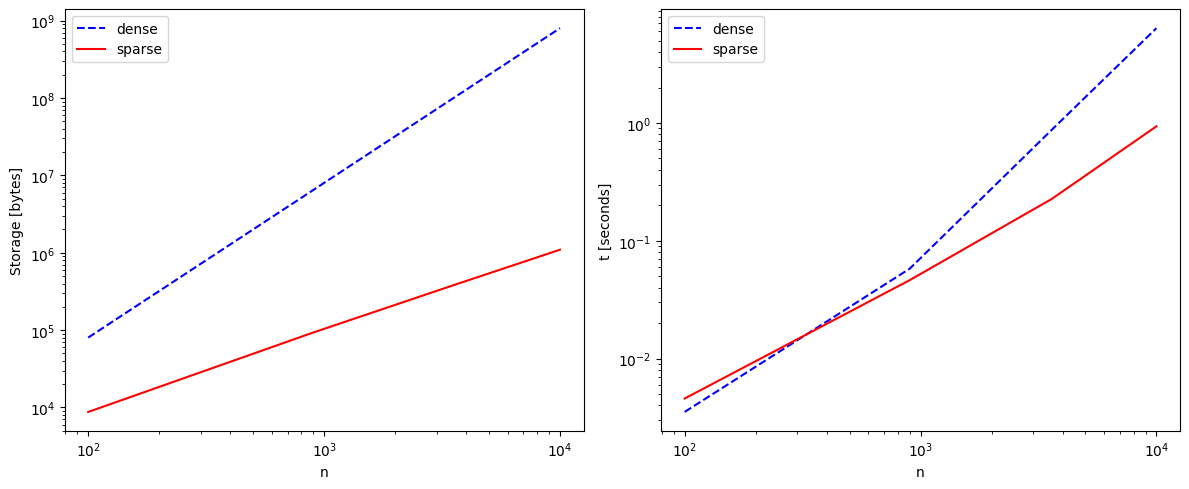

In [16]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot - Storage
ax1.plot(n, dense_storage, linestyle="--", color='blue', label="dense")
ax1.plot(n, sparse_storage, linestyle="-", color='red', label="sparse")
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_ylabel('Storage [bytes]')
ax1.set_xlabel('n')
ax1.legend()

# Second subplot - Time
ax2.plot(n, dense_time, linestyle="--", color='blue', label="dense")
ax2.plot(n, sparse_time, linestyle="-", color='red', label="sparse")
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.set_ylabel('t [seconds]')
ax2.set_xlabel('n')
ax2.legend()

plt.tight_layout()
plt.show()

# Stage 2

In [21]:
# if you fail to implement linear, go with rectangular case!
shape =  'linear'    # 'rectangular', 'linear',  'quadratic', 'crazy'

l = 1
# Set up values
dimX, dimY = 30, 30
X, Y = setUpMesh(dimX, dimY, l, formfunction, shape)

boundary =   ['D', 'N', 'D', 'R'] # [N,S,W,E] : D : Dirichlet, N : Neumann, R : Robin
TD =  [100 , 100 , 300 , 100] # [N,S,W,E]
alpha = 20
Tinf = 90
q = 0
heat = CustomSteadyHeat2D_FVM(X, Y, boundary, TD, q, alpha, Tinf)
solvers = ['jacobi', 'gauss_seidel', 'sor']
iteration_data = {
    'jacobi' : 0,
    'gauss_seidel' : 0,
    'sor' : 0
}
for solver in solvers:
    T = heat.custom_solve(solver, max_iter=6000, tol=1e-3, omega=1.25)
    iteration_data[solver] = heat.it_history

Jacobi: Converged in 4634 iterations with L2 norm 0.0009985843865165163
GS: Converged in 2497 iterations with L2 norm 0.000996573923454207
SOR: Converged in 1576 iterations with L2 norm 0.000995037721225545
